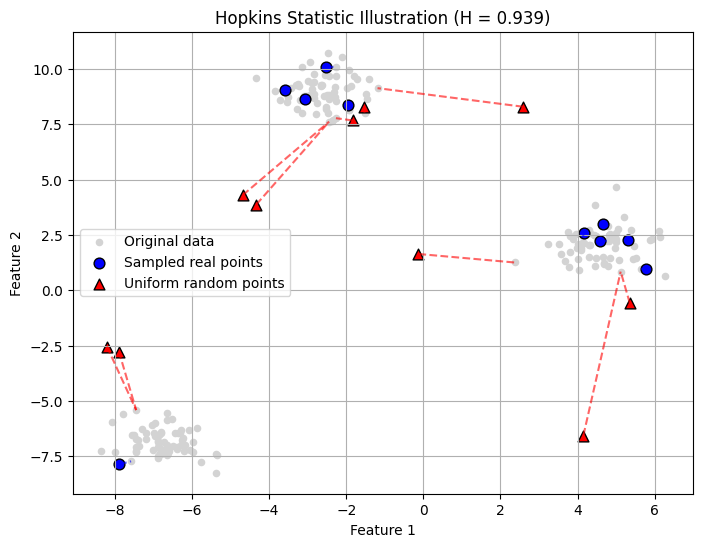

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
import random

# ------------------------------------------------------
# STEP 1 — Create Artificial Clustered Data
# ------------------------------------------------------
X, _ = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=42)

# Randomly select a few sample points from the real data
m = 10
sample_indices = random.sample(range(0, X.shape[0]), m)
X_sample = X[sample_indices]

# ------------------------------------------------------
# STEP 2 — Generate Uniformly Random Points
# ------------------------------------------------------
mins, maxs = np.min(X, axis=0), np.max(X, axis=0)
X_uniform = np.random.uniform(mins, maxs, (m, X.shape[1]))

# ------------------------------------------------------
# STEP 3 — Compute Distances
# ------------------------------------------------------
nbrs = NearestNeighbors(n_neighbors=2).fit(X)

# Distance from each random (uniform) point to the nearest data point → u_i
u_dist = [nbrs.kneighbors([x], 1, return_distance=True)[0][0][0] for x in X_uniform]

# Distance from each sampled real point to its nearest neighbor in the data (excluding itself) → w_i
w_dist = [nbrs.kneighbors([x], 2, return_distance=True)[0][0][1] for x in X_sample]

# Hopkins statistic
H = sum(u_dist) / (sum(u_dist) + sum(w_dist))

# ------------------------------------------------------
# STEP 4 — Visualization
# ------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], s=20, c='lightgray', label='Original data')
plt.scatter(X_sample[:,0], X_sample[:,1], c='blue', s=60, edgecolors='black', label='Sampled real points')
plt.scatter(X_uniform[:,0], X_uniform[:,1], c='red', s=60, marker='^', edgecolors='black', label='Uniform random points')

# Draw lines from uniform random points to their nearest data point
for i in range(m):
    # Nearest neighbor of random point
    nearest_idx = nbrs.kneighbors([X_uniform[i]], 1, return_distance=False)[0][0]
    nearest_point = X[nearest_idx]
    plt.plot([X_uniform[i,0], nearest_point[0]], [X_uniform[i,1], nearest_point[1]], 'r--', alpha=0.6)

# Draw lines from sampled real points to their nearest neighbor
for i in range(m):
    # Second nearest neighbor of real point
    nearest_idx = nbrs.kneighbors([X_sample[i]], 2, return_distance=False)[0][1]
    nearest_point = X[nearest_idx]
    plt.plot([X_sample[i,0], nearest_point[0]], [X_sample[i,1], nearest_point[1]], 'b--', alpha=0.6)

plt.title(f"Hopkins Statistic Illustration (H = {H:.3f})")
plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()


Hopkins Statistic (Clustered Data): 0.977
Hopkins Statistic (Random Data): 0.533


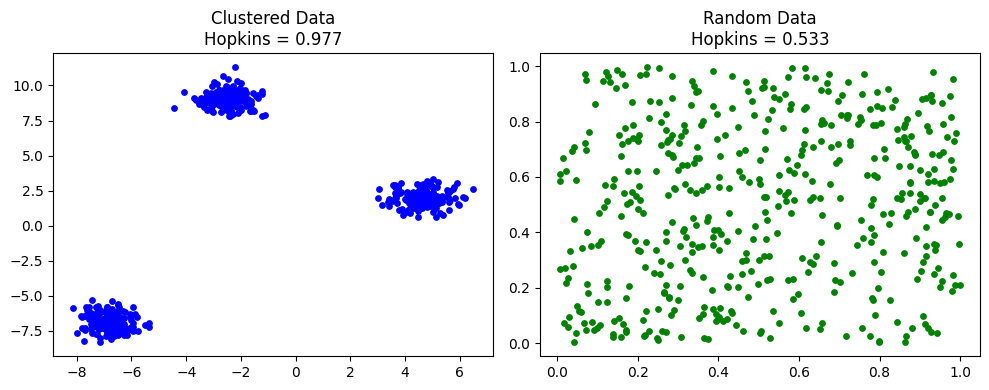

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
import random

# --- Hopkins Statistic Function ---
def hopkins(X, sampling_size=0.1):
    if isinstance(X, pd.DataFrame):
        X = X.values
    n, d = X.shape
    m = int(sampling_size * n)

    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    rand_X = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))

    u_dist = []
    w_dist = []

    for rand_point in rand_X:
        u_dist.append(nbrs.kneighbors([rand_point], 1, return_distance=True)[0][0][0])

    random_indices = random.sample(range(0, n), m)
    for i in random_indices:
        sample = X[i].reshape(1, -1)
        w_dist.append(nbrs.kneighbors(sample, 2, return_distance=True)[0][0][1])  # 2nd neighbor

    H = sum(u_dist) / (sum(u_dist) + sum(w_dist))
    return H

# --- Create Clustered Data ---
X_clustered, _ = make_blobs(n_samples=500, n_features=2, centers=3, cluster_std=0.6, random_state=42)

# --- Create Random Data ---
X_random = np.random.rand(500, 2)

# --- Compute Hopkins Statistic ---
H_clustered = hopkins(X_clustered)
H_random = hopkins(X_random)

# --- Print Results ---
print(f"Hopkins Statistic (Clustered Data): {H_clustered:.3f}")
print(f"Hopkins Statistic (Random Data): {H_random:.3f}")

# --- Plot ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_clustered[:,0], X_clustered[:,1], s=15, color='blue')
ax[0].set_title(f"Clustered Data\nHopkins = {H_clustered:.3f}")
ax[1].scatter(X_random[:,0], X_random[:,1], s=15, color='green')
ax[1].set_title(f"Random Data\nHopkins = {H_random:.3f}")
plt.tight_layout()
plt.show()
